In [1]:
import pandas as pd

# Superstore Sales & Profit Analysis

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("../data/archive/Sample - Superstore.csv",encoding="latin1") 

## 1. Data Overview & Data Cleaning

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [7]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df.isnull().sum() 

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## 2. Overall Business Performance

In [13]:
df['Sales'].sum()

np.float64(2297200.8603)

In [15]:
df['Profit'].sum()  

np.float64(286397.0217)

In [9]:
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100 
print("Overall Profit Margin:", profit_margin, 2, "%")
 

Overall Profit Margin: 12.467217240315605 2 %


## 3. Profit by Category

In [16]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [17]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

## 4. Profit Margin by Category

In [18]:
category_summary = df.groupby('Category')[['Sales','Profit']].sum()
category_summary['Profit Margin'] = (category_summary['Profit'] / category_summary['Sales']) * 100

In [19]:
category_summary

,Sales,Profit,Profit Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


## 5. Profit by Sub-category

In [20]:
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [21]:
profit_by_subcategory = df.groupby('Sub-Category')['Profit'].sum()

print("Most profitable:", profit_by_subcategory.idxmax())
print("Least profitable:", profit_by_subcategory.idxmin())
 

Most profitable: Copiers
Least profitable: Tables


## 6. Regional Performance

In [22]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
 

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [23]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [24]:
print("Total Sales:", df['Sales'].sum())   
print("Total Profit:", df['Profit'].sum())

Total Sales: 2297200.8603
Total Profit: 286397.0217


## 7. Yearly Performance

In [26]:
df['Year'] = df['Order Date'].dt.year

In [28]:
df.groupby('Year')['Sales'].sum()

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

In [29]:
df.groupby('Year')['Profit'].sum()

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

## 8. Sales Trend

<Axes: title={'center': 'Sales Trend by'}, xlabel='Year'>

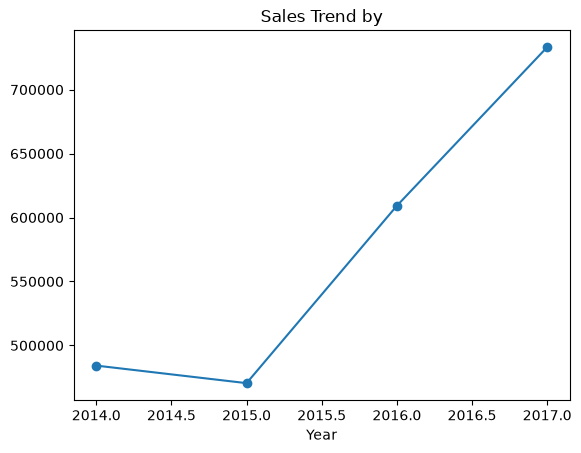

In [30]:
sales_by_year = df.groupby('Year')['Sales'].sum()
sales_by_year.plot(kind='line', marker='o', title='Sales Trend by')   

## 9. Profit Trend

<Axes: title={'center': 'Profit Trend by Year'}, xlabel='Year'>

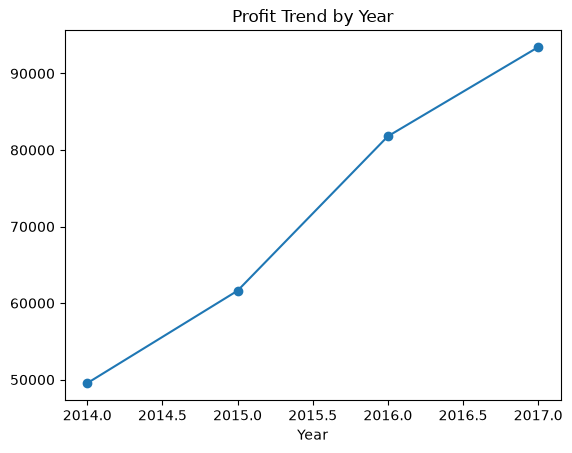

In [32]:
profit_by_year = df.groupby('Year')['Profit'].sum()
profit_by_year.plot(kind='line', marker='o', title='Profit Trend by Year' )

## 10. Key Findings & Recommendations

### Key Findings
- Technology generated the highest total profit among the three categories.
- Furniture had the lowest profit margin at approximately 2,49%.
- Copiers were the most profitable sub-category.
- Tables were the least profitable sub-category and generated an overall loss.
- The West region recorded the highest sales and the highest profit.
- Sales increased overall from 2014 to 2017, with 2017 recording the highest sales.
- Profit increased every year from 2014 to 2017.
- The overall profit margin was apporximately 12.46%.

### Recommendations
- Investigate the low profitability of Furniture.
- Review pricing, costs, and discount levels for Tables.
- Identify factors contributing to the strong performance of Technology and Copiers.
- Investigate difference between regional sales and profitability. 
- Review discount patterns to determine their effect on profit margins.

